In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('twitter_training.csv')
val_df = pd.read_csv('twitter_validation.csv')

In [3]:
df1 = df.copy()

In [4]:
# %pip install spacy
# !python -m spacy download en_core_web_lg

import spacy
nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])

In [5]:
import contractions
import re
import emoji
from bs4 import BeautifulSoup

def preprocess_text(text):
    # Converts emoji to text
    text = emoji.demojize(text)
    text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags
    
    text = contractions.fix(text)  # Expand contractions
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Reduce repeated characters
    text=re.sub(r"[@#^<>|(){}[\]\~*+=]", " ", text) # Remove less important special characters
    text=re.sub(r"\s+", " ", text)
    text = text.strip()  # Remove leading and trailing spaces
    return text

In [6]:
df1['tweet_content'] = df1['tweet_content'].apply(lambda x: preprocess_text(x))
val_df['tweet_content'] = val_df['tweet_content'].apply(lambda x: preprocess_text(x))

/tmp/ipykernel_1900/142434363.py:9: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags


In [7]:
def check_for_only_spaces_or_punctuations(text):
    # Check if the text contains only spaces or punctuation
    if not text or text.isspace() or re.match(r'^[\W_]+$', text):
        return True
    
    doc = nlp(text)
    
    if all (token.is_punct or token.is_space for token in doc):
        return True
    
    return False

In [8]:
df1['status'] = df1['tweet_content'].apply(check_for_only_spaces_or_punctuations)

In [9]:
df1.drop(df1[df1['status'] == True].index, inplace=True)

In [13]:
df1

,tID,entity,sentiment,tweet_content,status
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,False
1,2401,Borderlands,Positive,i am getting on borderlands and i will kill yo...,False
2,2401,Borderlands,Positive,i am coming on borderlands and i will murder y...,False
3,2401,Borderlands,Positive,i am getting on borderlands 2 and i will murde...,False
4,2401,Borderlands,Positive,i am getting into borderlands and i can murder...,False
...,...,...,...,...,...
73985,9200,Nvidia,Positive,just realized that the windows partition of my...,False
73986,9200,Nvidia,Positive,just realized that my mac window partition is ...,False
73987,9200,Nvidia,Positive,just realized the windows partition of my mac ...,False
73988,9200,Nvidia,Positive,just realized between the windows partition of...,False


In [10]:
df1.drop(columns=['status','tID'], inplace=True)

In [11]:
df1.drop_duplicates(inplace=True)

In [12]:
df1.reset_index(drop=True, inplace=True)

In [13]:
val_df.drop(columns=['ID'], inplace=True)

In [14]:
df = df1.copy()

In [36]:
def remove_stopword(text):
    doc = nlp(text)
    filtered_tokens = [token.text for token in doc if not token.is_stop]
    return " ".join(filtered_tokens)

In [37]:
df['stopword_text'] =df['tweet_content'].apply(remove_stopword)



In [15]:
def lem(text_col, cat_col, data):
    data[text_col]=data[cat_col].astype(str)+" "+data[text_col].astype(str) # Concatenate the 'games' column content with the 'tweets' column content
    lemm=[" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(data[text_col], batch_size=256, n_process=-1)] # Perform lemmatization using spaCy's nlp.pipe for efficient batch processing
    return pd.Series(lemm, index=data.index)



In [16]:
df['lemmatized_text'] = lem('tweet_content', 'entity', df)

In [17]:
val_df['lemmatized_text'] = lem('tweet_content', 'entity', val_df)

In [18]:
def tokenize(text):
    tokens = []
    for token in nlp(text.lower()):
        tokens.append(token.text)
    return tokens

In [19]:
df['tokenized_text'] = df['lemmatized_text'].apply(tokenize)

In [20]:
val_df['tokenized_text'] = val_df['lemmatized_text'].apply(tokenize)

In [40]:
df['stop_lem_text'] = df['stop_lem_text'].apply(tokenize)

In [25]:
def lem_single(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)


In [24]:
from collections import Counter

def word_occurrence(df):
    sentences = []
    for _ , row in df.iterrows():
        text = row['tokenized_text']   
       
        sentences.extend(text)
    
    vocab = {'<unk>': 0}
    
    for token in Counter(sentences):
        if token not in vocab:
            vocab[token] = len(vocab)
    
    return vocab
    
        

In [25]:
vocab = word_occurrence(df)

In [26]:
def replace_word_with_numbers(text):
    tokens = []
    for token in text:
        if token in vocab:
            tokens.append(vocab[token])
        else:
            tokens.append(vocab['<unk>'])
    return tokens

In [73]:
df['tokenized_text_in_numbers'] = df['tokenized_text'].apply(replace_word_with_numbers)

In [28]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text'].apply(replace_word_with_numbers)

In [44]:
df['stop_lem_text'].head()

0            [borderland, come, border, kill, ,]
1         [borderland, get, borderland, kill, ,]
2      [borderland, come, borderland, murder, ,]
3    [borderland, get, borderland, 2, murder, ,]
4       [borderland, get, borderland, murder, ,]
Name: stop_lem_text, dtype: object

In [45]:
df['stopword_tokenized_text_in_numbers'].head()

0       [1, 2, 3, 4, 5]
1       [1, 6, 1, 4, 5]
2       [1, 2, 1, 7, 5]
3    [1, 6, 1, 8, 7, 5]
4       [1, 6, 1, 7, 5]
Name: stopword_tokenized_text_in_numbers, dtype: object

In [60]:
def lem_single(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)


In [78]:
def padding(text):
    max_len = 200
    if len(text) > max_len:
        max_len = len(text)
    return [text + [0] * (max_len - len(text)) ]

In [ ]:
df['tokenized_text_in_numbers'].apply(padding)

In [31]:
def padding(text):
    max_len = max(len(text) for text in df['tokenized_text_in_numbers'])
    return [text + [0] * (max_len - len(text)) for text in text]

In [32]:
df['tokenized_text_in_numbers'] = padding(df['tokenized_text_in_numbers'])

In [33]:
val_df['tokenized_text_in_numbers'] = padding(val_df['tokenized_text_in_numbers'])

In [35]:
X = df['tokenized_text_in_numbers']
y = df['sentiment']
X_val = val_df['tokenized_text_in_numbers']
y_val = val_df['sentiment']

In [36]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_lbl = label_encoder.fit_transform(y)

In [37]:
# Prepare the test data


y_val_lbl = label_encoder.transform(y_val)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_lbl, random_state=42)

In [39]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [40]:
from torch.utils.data import Dataset
import numpy as np

class NLPdataCustom(Dataset):
    
    def __init__(self, X_feature,y_label):
        
        # Convert to NumPy arrays first
        X_np = np.array(X_feature.tolist())  # Ensures 2D shape if Series contains lists
        y_np = np.array(y_label.tolist()) 
        
        
        self.X = torch.tensor(X_np ,dtype=torch.long)
        self.y = torch.tensor(y_np, dtype=torch.long)
        
        
    def __len__(self):
        return len(self.X)
    
    
    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        
        return X, y
    



In [41]:
train_data_set = NLPdataCustom(X_train, y_train)
test_data_set = NLPdataCustom(X_test, y_test)

In [42]:
print("Unique labels:", train_data_set.y.unique())
print("Max label:", train_data_set.y.max().item())
print("Min label:", train_data_set.y.min().item())
print("Output classes expected:", len(train_data_set.y.unique()))


Unique labels: tensor([0, 1, 2, 3])
Max label: 3
Min label: 0
Output classes expected: 4


In [43]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataloader_custom = DataLoader(dataset=train_data_set,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     pin_memory=True)
                                    #  num_workers=1)

test_dataloader_custom = DataLoader(dataset=test_data_set,
                                    batch_size=BATCH_SIZE,
                                    pin_memory=True,
                                    shuffle=False)

In [44]:
class LSTMModelV1(nn.Module):

    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, drop_out, bi_directional , output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=bi_directional, dropout=drop_out)
        self.dropout = nn.Dropout(drop_out)
        self.linear = nn.Linear(hidden_size * 2 if bi_directional else hidden_size, output_dim) # Adjust linear layer size based on bidirectionality
        self.bi_directional = bi_directional


    def forward(self, x):

        num_directions = 2 if self.bi_directional else 1
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))

        if self.bi_directional:
             # hidden[-2,:,:] corresponds to the last layer's forward hidden state
            # hidden[-1,:,:] corresponds to the last layer's backward hidden state
            hidden_combined = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden_combined = self.dropout(hidden[-1,:,:]) # Use only the last layer's hidden state for unidirectional LSTM

        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)

        return out

In [ ]:
class LSTMModel(nn.Module):
    
    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(hidden_size * 2, output_dim)
        
        
    def forward(self, x):
        
        num_directions = 2
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))
         # hidden[-2,:,:] corresponds to the last layer's forward hidden state
        # hidden[-1,:,:] corresponds to the last layer's backward hidden state
        hidden_combined = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)
        
        return out

In [45]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device):



    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward propagation
        y_pred = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. optimizer zero grad
        optimizer.zero_grad()

        # 4. loss backward
        loss.backward()

        # 5. optimizer step
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)


    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)


    return train_loss, train_acc



In [46]:
def test_step(model,
              dataloader,
              loss_fn,
              device):



    model.eval()

    test_loss, test_acc = 0, 0


    with torch.inference_mode():
        for batch , (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))



    test_loss = test_loss / len(dataloader)

    test_acc = test_acc / len(dataloader)


    return test_loss, test_acc



In [47]:
from tqdm.auto import tqdm


def train(model,
          train_dataloader,
          test_dataloader,
          loss_fn,
          optimizer,
          epochs,
          device):


    results = {"train_loss": [],
               "train_acc": [],
               "test_loss":[],
               "test_acc":[]}


    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model,
                                           train_dataloader,
                                           loss_fn,
                                           optimizer,
                                           device)


        test_loss, test_acc = test_step(model,
                                        test_dataloader,
                                        loss_fn,
                                        device)


        print(f"Epoch: {epoch+1} |  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}" )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [53]:
def objective(trial):

  num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
  num_hidden_units = trial.suggest_int("num_hidden_units", 8, 128, step=8)
  dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
  epoch_num = trial.suggest_int("epoch_num", 10, 50, step=10)
  batch_size = trial.suggest_int("batch_size", 32, 128, step=32)
  bi_directional = trial.suggest_categorical("bi_directional", [True, False])
  optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"])
  weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

  model = LSTMModel(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=num_hidden_units,
                  layer_dim=num_hidden_layers,
                  drop_out = dropout_rate,
                  bi_directional = bi_directional,
                  output_dim=len(train_data_set.y.unique())
                  ).to(device)

  train_dataloader_custom = DataLoader(dataset=train_data_set,
                                     batch_size=batch_size,
                                     shuffle=True,
                                     pin_memory=True)
                                    #  num_workers=1)

  test_dataloader_custom = DataLoader(dataset=test_data_set,
                                    batch_size=batch_size,
                                    pin_memory=True,
                                    shuffle=False)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)


  if optimizer_name == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  elif optimizer_name == "RMSprop":
    optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  else:
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)


  model_results = train(model=model,
                      train_dataloader=train_dataloader_custom,
                      test_dataloader=test_dataloader_custom,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=epoch_num,
                      device=device)

  return model_results['test_acc'][-1]

In [54]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 582.2/582.2 kB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]]my]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [55]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2025-08-06 05:38:40,919] A new study created in memory with name: no-name-bfa768e9-dfdb-4528-845a-31bebeda6add


In [56]:
study.optimize(objective, n_trials=20)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.3912 | Train acc: 0.2974 | Test loss: 1.3876 | Test acc: 0.3029
Epoch: 2 |  Train loss: 1.3856 | Train acc: 0.3021 | Test loss: 1.3826 | Test acc: 0.3029
Epoch: 3 |  Train loss: 1.3816 | Train acc: 0.3035 | Test loss: 1.3789 | Test acc: 0.3029
Epoch: 4 |  Train loss: 1.3787 | Train acc: 0.3029 | Test loss: 1.3760 | Test acc: 0.3029
Epoch: 5 |  Train loss: 1.3766 | Train acc: 0.3022 | Test loss: 1.3738 | Test acc: 0.3029
Epoch: 6 |  Train loss: 1.3745 | Train acc: 0.3021 | Test loss: 1.3721 | Test acc: 0.3029
Epoch: 7 |  Train loss: 1.3736 | Train acc: 0.3026 | Test loss: 1.3708 | Test acc: 0.3029
Epoch: 8 |  Train loss: 1.3726 | Train acc: 0.3022 | Test loss: 1.3698 | Test acc: 0.3029
Epoch: 9 |  Train loss: 1.3719 | Train acc: 0.3008 | Test loss: 1.3689 | Test acc: 0.3029
Epoch: 10 |  Train loss: 1.3715 | Train acc: 0.3014 | Test loss: 1.3683 | Test acc: 0.3029
Epoch: 11 |  Train loss: 1.3712 | Train acc: 0.3007 | Test loss: 1.3678 | Test acc: 0.3029
Epoch: 1

[I 2025-08-06 05:42:47,727] Trial 0 finished with value: 0.3028980057932264 and parameters: {'num_hidden_layers': 5, 'num_hidden_units': 8, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0010067886210374433, 'epoch_num': 50, 'batch_size': 128, 'bi_directional': True, 'optimizer': 'SGD', 'weight_decay': 0.0008192737833766866}. Best is trial 0 with value: 0.3028980057932264.


Epoch: 50 |  Train loss: 1.3691 | Train acc: 0.3004 | Test loss: 1.3654 | Test acc: 0.3029


  0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch: 40 |  Train loss: 1.3688 | Train acc: 0.3035 | Test loss: 1.3653 | Test acc: 0.3029


  0%|          | 0/40 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.1066 | Train acc: 0.5308 | Test loss: 1.0408 | Test acc: 0.5783
Epoch: 2 |  Train loss: 0.9049 | Train acc: 0.6440 | Test loss: 1.3618 | Test acc: 0.5255
Epoch: 3 |  Train loss: 0.7975 | Train acc: 0.6965 | Test loss: 1.0603 | Test acc: 0.5804
Epoch: 4 |  Train loss: 0.7298 | Train acc: 0.7221 | Test loss: 0.9685 | Test acc: 0.6526
Epoch: 5 |  Train loss: 0.6744 | Train acc: 0.7469 | Test loss: 0.7221 | Test acc: 0.7305
Epoch: 6 |  Train loss: 0.6240 | Train acc: 0.7681 | Test loss: 0.6991 | Test acc: 0.7295
Epoch: 7 |  Train loss: 0.5777 | Train acc: 0.7876 | Test loss: 0.8176 | Test acc: 0.6654
Epoch: 8 |  Train loss: 0.5362 | Train acc: 0.8034 | Test loss: 0.6438 | Test acc: 0.7597
Epoch: 9 |  Train loss: 0.4915 | Train acc: 0.8220 | Test loss: 0.6130 | Test acc: 0.7800
Epoch: 10 |  Train loss: 0.4552 | Train acc: 0.8357 | Test loss: 0.7863 | Test acc: 0.7143
Epoch: 11 |  Train loss: 0.4251 | Train acc: 0.8466 | Test loss: 0.5644 | Test acc: 0.7942
Epoch: 1

[I 2025-08-06 08:04:27,360] Trial 19 finished with value: 0.6912913602941176 and parameters: {'num_hidden_layers': 3, 'num_hidden_units': 24, 'dropout_rate': 0.1, 'learning_rate': 0.0020020071285389834, 'epoch_num': 40, 'batch_size': 64, 'bi_directional': True, 'optimizer': 'RMSprop', 'weight_decay': 0.0003761730936206449}. Best is trial 11 with value: 0.8774126838235294.


Epoch: 40 |  Train loss: 0.2443 | Train acc: 0.9142 | Test loss: 1.0977 | Test acc: 0.6913


In [58]:
study.best_params

{'num_hidden_layers': 1,
 'num_hidden_units': 48,
 'dropout_rate': 0.2,
 'learning_rate': 0.005981057556391124,
 'epoch_num': 30,
 'batch_size': 64,
 'bi_directional': True,
 'optimizer': 'RMSprop',
 'weight_decay': 1.019552870543316e-05}

In [67]:
best_params = {'num_hidden_layers': 1,
 'num_hidden_units': 48,
 'dropout_rate': 0.2,
 'learning_rate': 0.005981057556391124,
 'epoch_num': 30,
 'batch_size': 64,
 'bi_directional': True,
 'optimizer': 'RMSprop',
 'weight_decay': 1.019552870543316e-05}

In [59]:
model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=64,
                  layer_dim=2,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=len(train_data_set.y.unique())
                  ).to(device)



train_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.RMSprop(params=model.parameters(), lr=0.005981057556391124, weight_decay=1.019552870543316e-05)


model_results = train(model=model,
                      train_dataloader=train_dataloader_custom,
                      test_dataloader=test_dataloader_custom,
                      optimizer=optimizer,
                      loss_fn=train_loss_fn,
                      epochs=50,
                      device=device)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 0.9647 | Train acc: 0.6074 | Test loss: 0.8402 | Test acc: 0.6681
Epoch: 2 |  Train loss: 0.5675 | Train acc: 0.7939 | Test loss: 0.5561 | Test acc: 0.7956
Epoch: 3 |  Train loss: 0.3899 | Train acc: 0.8616 | Test loss: 0.4509 | Test acc: 0.8404
Epoch: 4 |  Train loss: 0.3104 | Train acc: 0.8912 | Test loss: 0.4791 | Test acc: 0.8373
Epoch: 5 |  Train loss: 0.2731 | Train acc: 0.9026 | Test loss: 0.3938 | Test acc: 0.8664
Epoch: 6 |  Train loss: 0.2454 | Train acc: 0.9146 | Test loss: 0.3870 | Test acc: 0.8697
Epoch: 7 |  Train loss: 0.2264 | Train acc: 0.9194 | Test loss: 0.3880 | Test acc: 0.8690
Epoch: 8 |  Train loss: 0.2128 | Train acc: 0.9245 | Test loss: 0.4234 | Test acc: 0.8543
Epoch: 9 |  Train loss: 0.2048 | Train acc: 0.9288 | Test loss: 0.3731 | Test acc: 0.8710
Epoch: 10 |  Train loss: 0.1927 | Train acc: 0.9330 | Test loss: 0.3957 | Test acc: 0.8728
Epoch: 11 |  Train loss: 0.1862 | Train acc: 0.9345 | Test loss: 0.3448 | Test acc: 0.8881
Epoch: 1

In [55]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]

  test_loss = results["test_loss"]

  accuracy = results["train_acc"]

  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

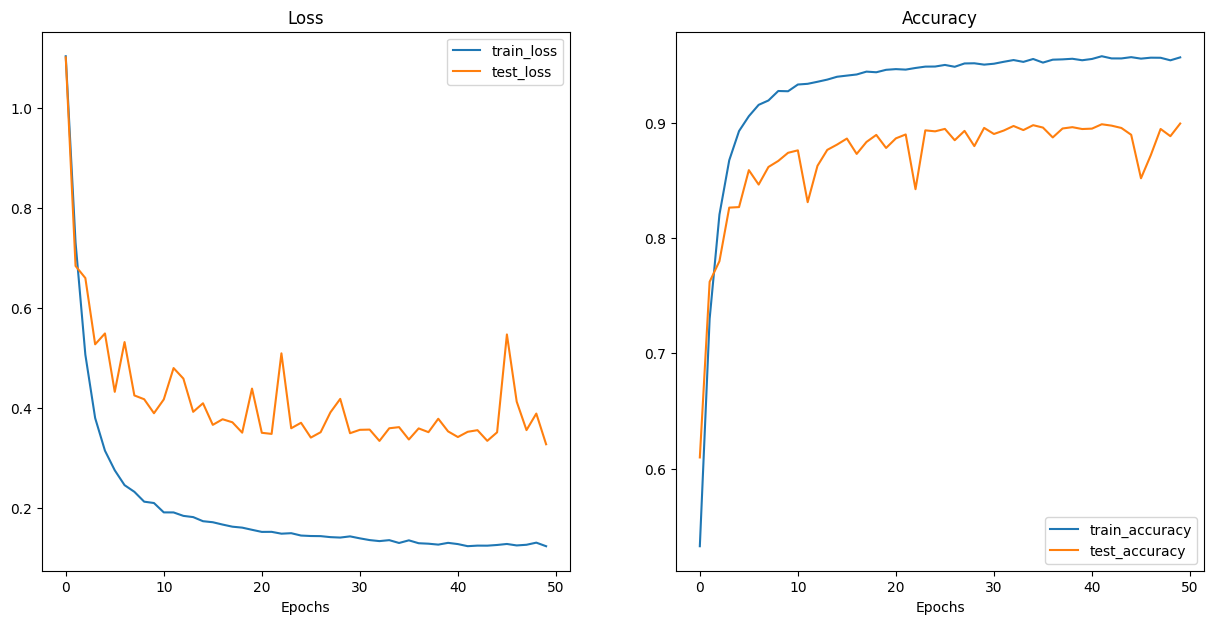

In [56]:
plot_loss_curves(model_results)